# Matemáticas Aplicadas a Ciencia de Datos: Examen 1 — Versión 2

**Alumno:** Saúl Ibrahim García Morales  
**Licenciatura en Ciencia de Datos e Inteligencia Artificial**  
**Profesor:** Iván Alejandro Toledano Juárez  
**Semestre:** 2026B — Aula N 105

## Contexto

Vamos a utilizar el dataset **mpg (Auto MPG)** que contiene información sobre automóviles de finales de los años 70 y principios de los 80. El dataset incluye variables técnicas y de rendimiento.

**Variables principales:**
- `mpg`: Millas por galón (eficiencia de combustible)
- `cylinders`: Número de cilindros (3, 4, 5, 6, 8)
- `displacement`: Desplazamiento del motor (pulgadas cúbicas)
- `horsepower`: Caballos de fuerza
- `weight`: Peso del automóvil (libras)
- `acceleration`: Tiempo para acelerar de 0 a 60 mph (**segundos**) - **Variable objetivo**
- `model_year`: Año del modelo (1970-1982)
- `origin`: Origen (1: USA, 2: Europa, 3: Japón)
- `name`: Nombre del modelo


In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [2]:
# Cargar el dataset
url = "https://raw.githubusercontent.com/IvTole/Matematicas_Aplicadas_Ciencia_De_Datos_CUGDL/refs/heads/main/data/cars/mpg.csv"
try:
    df = pd.read_csv("variantes_cars/mpg.csv")
except Exception:
    df = pd.read_csv(url)
df_global = df
df.head()


In [3]:
## Funciones de apoyo
def area_cdf(z):
    x = np.arange(-10, z, 0.001)
    x_full = np.arange(-10, 10, 0.001)
    plt.figure(figsize=(7, 3.5))
    plt.plot(x_full, stats.norm.pdf(x_full, 0, 1), color='#2563eb', linewidth=2)
    plt.fill_between(x, stats.norm.pdf(x, 0, 1), color='#3b82f6', alpha=0.5, label=f'Área acumulada (Z ≤ {z:.2f})')
    plt.title(f"Distribución Acumulada hasta Z = {z:.2f}", fontsize=12)
    plt.xlabel("Puntaje Z", fontsize=10)
    plt.ylabel("Densidad N(0, 1)", fontsize=10)
    plt.xlim(-4, 4)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

def area_between(z1, z2):
    x = np.arange(z1, z2, 0.001)
    x_full = np.arange(-10, 10, 0.001)
    plt.figure(figsize=(7, 3.5))
    plt.plot(x_full, stats.norm.pdf(x_full, 0, 1), color='#2563eb', linewidth=2)
    plt.fill_between(x, stats.norm.pdf(x, 0, 1), color='#10b981', alpha=0.5, label=f'Área entre [{z1:.2f}, {z2:.2f}]')
    plt.title(f"Área bajo la curva entre Z1 = {z1:.2f} y Z2 = {z2:.2f}", fontsize=12)
    plt.xlabel("Puntaje Z", fontsize=10)
    plt.ylabel("Densidad N(0, 1)", fontsize=10)
    plt.xlim(-4, 4)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

def area_cdf_c(z):
    x = np.arange(z, 10, 0.001)
    x_full = np.arange(-10, 10, 0.001)
    plt.figure(figsize=(7, 3.5))
    plt.plot(x_full, stats.norm.pdf(x_full, 0, 1), color='#2563eb', linewidth=2)
    plt.fill_between(x, stats.norm.pdf(x, 0, 1), color='#ef4444', alpha=0.5, label=f'Área complementaria (Z ≥ {z:.2f})')
    plt.title(f"Distribución Acumulada Complementaria desde Z = {z:.2f}", fontsize=12)
    plt.xlabel("Puntaje Z", fontsize=10)
    plt.ylabel("Densidad N(0, 1)", fontsize=10)
    plt.xlim(-4, 4)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


## Análisis Exploratorio de Datos

### Medidas de Tendencia Central y Dispersión

Para la variable **acceleration (tiempo para acelerar de 0 a 60 mph)**:

**a) Calcula la media, mediana y moda**. Escribe también sus unidades correspondientes.


In [4]:
media_acc = df["acceleration"].mean()
mediana_acc = df["acceleration"].median()
moda_acc = df["acceleration"].mode().iloc[0]

print(f"Media de acceleration:   {media_acc:.4f} segundos")
print(f"Mediana de acceleration: {mediana_acc:.4f} segundos")
print(f"Moda de acceleration:    {moda_acc:.4f} segundos")


Media de acceleration:   15.5681 segundos
Mediana de acceleration: 15.5000 segundos
Moda de acceleration:    14.5000 segundos


**b) Calcula la desviación estándar, varianza y rango intercuartílico (IQR)**. Escribe también sus unidades correspondientes.


In [5]:
std_acc = df["acceleration"].std()
var_acc = df["acceleration"].var()
q1_acc = df["acceleration"].quantile(0.25)
q3_acc = df["acceleration"].quantile(0.75)
iqr_acc = q3_acc - q1_acc

print(f"Desviación estándar (s):     {std_acc:.4f} segundos")
print(f"Varianza (s²):               {var_acc:.4f} segundos²")
print(f"Primer Cuartil (Q1 - 25%):   {q1_acc:.4f} segundos")
print(f"Tercer Cuartil (Q3 - 75%):   {q3_acc:.4f} segundos")
print(f"Rango Intercuartílico (IQR): {iqr_acc:.4f} segundos")


Desviación estándar (s):     2.7577 segundos
Varianza (s²):               7.6048 segundos²
Primer Cuartil (Q1 - 25%):   13.8250 segundos
Tercer Cuartil (Q3 - 75%):   17.1750 segundos
Rango Intercuartílico (IQR): 3.3500 segundos


**c) Interpreta estos resultados: ¿Qué te dicen sobre la aceleración de los automóviles en este dataset?**

*Respuesta:*

el tiempo promedio que tardan los automóviles en acelerar de 0 a 60 mph es de **15.57 segundos**, con una mediana de **15.50 segundos** y una moda de **14.50 segundos**. la cercanía entre media y mediana indica que la mayor parte de los vehículos de la muestra tienen un comportamiento centrado en torno a los 15.5 segundos.

la dispersión es moderada: una desviación estándar de **2.76 segundos** y un rango intercuartílico de **3.35 segundos** reflejan que el 50% central de los automóviles registra tiempos de aceleración situados en la ventana de **13.83 a 17.18 segundos**. existe una variabilidad razonable derivada de las diferencias en cilindraje y potencia entre los modelos compactos y los sedanes pesados de la época.


### Visualización

**a) Crea un histograma de la variable acceleration con al menos 10 bins.**


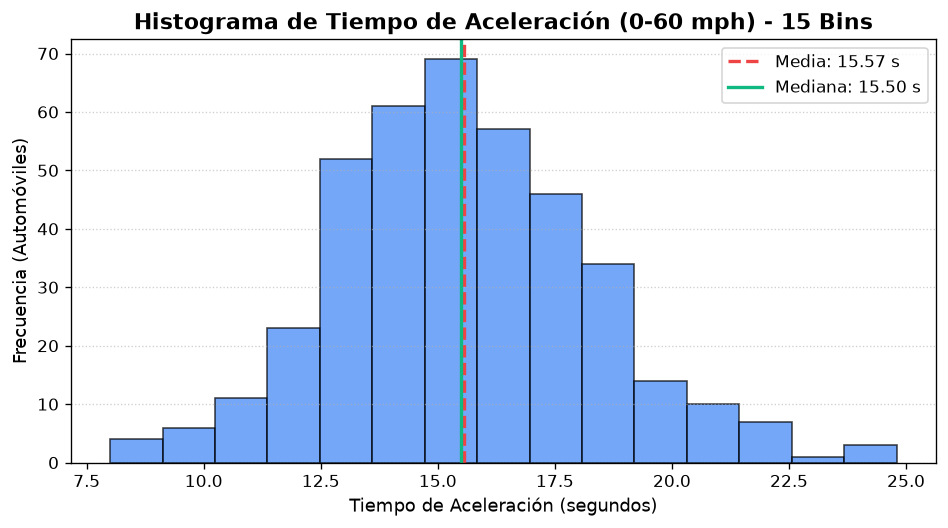

In [6]:
plt.figure(figsize=(8, 4.5))
plt.hist(df["acceleration"], bins=15, color="#3b82f6", edgecolor="black", alpha=0.7)
plt.axvline(df["acceleration"].mean(), color="#ef4444", linestyle="--", linewidth=2, label=f"Media: {df['acceleration'].mean():.2f} s")
plt.axvline(df["acceleration"].median(), color="#10b981", linestyle="-", linewidth=2, label=f"Mediana: {df['acceleration'].median():.2f} s")
plt.title("Histograma de Tiempo de Aceleración (0-60 mph) - 15 Bins", fontsize=13, fontweight="bold")
plt.xlabel("Tiempo de Aceleración (segundos)", fontsize=11)
plt.ylabel("Frecuencia (Automóviles)", fontsize=11)
plt.legend(frameon=True)
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()


**b) Crea un boxplot de acceleration. Identifica si existen outliers y menciona cuántos hay.**


Límites de Tukey: [8.8000, 22.2000] segundos
Cantidad total de outliers: 7
Valores de outliers: [8.0, 8.5, 8.5, 23.5, 23.7, 24.6, 24.8]


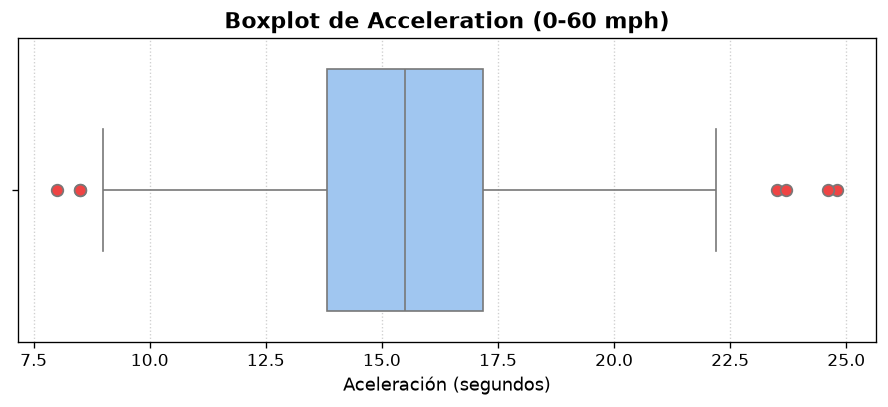

In [7]:
plt.figure(figsize=(7.5, 3.5))
sns.boxplot(x=df["acceleration"], color="#93c5fd", flierprops=dict(marker="o", markerfacecolor="#ef4444", markersize=7))
plt.title("Boxplot de Acceleration (0-60 mph)", fontsize=13, fontweight="bold")
plt.xlabel("Aceleración (segundos)", fontsize=11)
plt.grid(axis="x", linestyle=":", alpha=0.6)
plt.tight_layout()

q1 = df["acceleration"].quantile(0.25)
q3 = df["acceleration"].quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr
outliers = df[(df["acceleration"] < lim_inf) | (df["acceleration"] > lim_sup)]
print(f"Límites de Tukey: [{lim_inf:.4f}, {lim_sup:.4f}] segundos")
print(f"Cantidad total de outliers: {len(outliers)}")
print(f"Valores de outliers: {sorted(outliers['acceleration'].tolist())}")


*Respuesta:*

el boxplot revela la existencia de **7 outliers estadísticos** fuera de los bigotes calculados con la regla de tukey ($[8.80, 22.20]$ segundos):
- **3 outliers en la cola inferior** (automóviles de aceleración excepcionalmente rápida, tiempos menores a 8.80 s): `[8.0, 8.5, 8.5]` segundos.
- **4 outliers en la cola superior** (automóviles de aceleración muy lenta, tiempos mayores a 22.20 s): `[23.5, 23.7, 24.6, 24.8]` segundos.


**c) Crea un scatter plot entre weight (eje x) y acceleration (eje y). ¿Qué relación observas?**


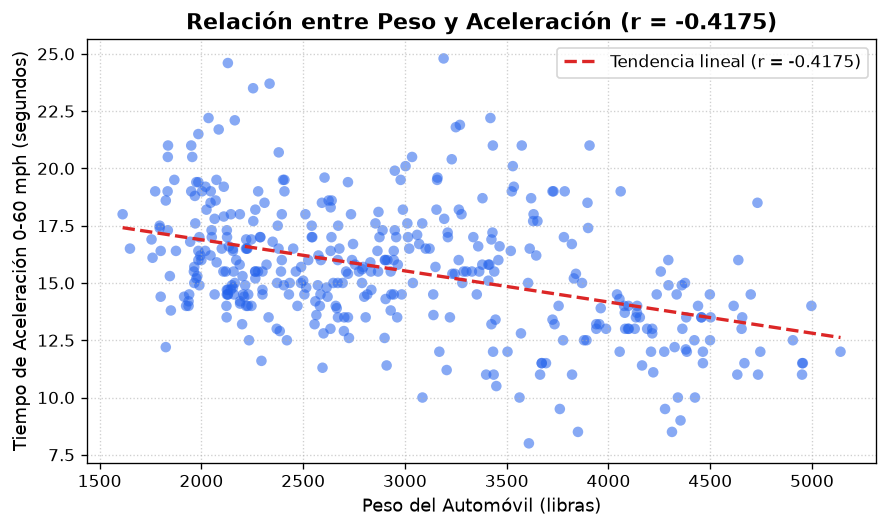

In [8]:
r_corr = df["weight"].corr(df["acceleration"])
plt.figure(figsize=(7.5, 4.5))
plt.scatter(df["weight"], df["acceleration"], color="#2563eb", alpha=0.55, edgecolors="none", s=40)
m, b = np.polyfit(df["weight"], df["acceleration"], 1)
x_line = np.linspace(df["weight"].min(), df["weight"].max(), 200)
plt.plot(x_line, m * x_line + b, color="#dc2626", linestyle="--", linewidth=2, label=f"Tendencia lineal (r = {r_corr:.4f})")

plt.title(f"Relación entre Peso y Aceleración (r = {r_corr:.4f})", fontsize=13, fontweight="bold")
plt.xlabel("Peso del Automóvil (libras)", fontsize=11)
plt.ylabel("Tiempo de Aceleración 0-60 mph (segundos)", fontsize=11)
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()


*Respuesta:*

se observa una **relación lineal negativa moderada** ($r = -0.4175$). a mayor peso del automóvil, el tiempo en segundos para alcanzar las 60 mph tiende a ser menor (es decir, aceleran más rápido en tiempo).

este fenómeno histórico en los automóviles de los años 70 se explica porque los vehículos más pesados estaban equipados con motores v8 de gran cilindrada y alto torque, lo que les permitía tiempos de aceleración más cortos a pesar de su masa, mientras que los compactos de 4 cilindros y bajo peso tenían motores pequeños y lentos.


### Análisis de Distribución

**a) Observando el histograma de acceleration, ¿consideras que la distribución es aproximadamente simétrica, sesgada a la derecha o sesgada a la izquierda? Justifica tu respuesta**

*Respuesta:*

la distribución de `acceleration` es **aproximadamente simétrica con una leve cola hacia la derecha (ligero sesgo positivo)**.

el histograma exhibe una típica forma acampanada con el cuerpo principal centrado de 14 a 17 segundos. no obstante, la presencia de 4 outliers con tiempos prolongados (hasta 24.8 s) alarga suavemente la cola derecha en comparación con la cola izquierda.


**b) Compara la media y la mediana de acceleration. ¿Qué te indica esta comparación sobre la simetría de los datos?**

*Respuesta:*

- **media**: $15.5681$ segundos
- **mediana**: $15.5000$ segundos

la media y la mediana son **prácticamente idénticas** ($\Delta = 0.0681$ segundos, una diferencia relativa inferior al $0.4\%$). al cumplirse de forma casi exacta $\text{media} \approx \text{mediana}$ con una discrepancia mínima hacia arriba ($\text{media} > \text{mediana}$ por centésimas), se confirma que la distribución posee un alto grado de **simetría central**, con un sesgo positivo prácticamente despreciable.


## Distribución Gaussiana

### Ajuste de Distribución Normal

Considera la variable **acceleration (tiempo de aceleración)**.

**a) Estima los parámetros μ (media) y σ (desviación estándar) de una distribución normal que se ajuste a los datos de acceleration.**


In [9]:
mu_acc = df["acceleration"].mean()
sigma_acc = df["acceleration"].std()
mu_global = mu_acc
sigma_global = sigma_acc

print(f"Parámetro μ (Media estimada):                {mu_acc:.4f} segundos")
print(f"Parámetro σ (Desviación estándar estimada):  {sigma_acc:.4f} segundos")
print(f"Parámetro σ² (Varianza estimada):            {sigma_acc**2:.4f} segundos²")


Parámetro μ (Media estimada):                15.5681 segundos
Parámetro σ (Desviación estándar estimada):  2.7577 segundos
Parámetro σ² (Varianza estimada):            7.6048 segundos²


**b) Crea un gráfico que superponga:**
- **El histograma normalizado (densidad) de acceleration**
- **La curva de la distribución normal N(μ, σ²) con los parámetros estimados**


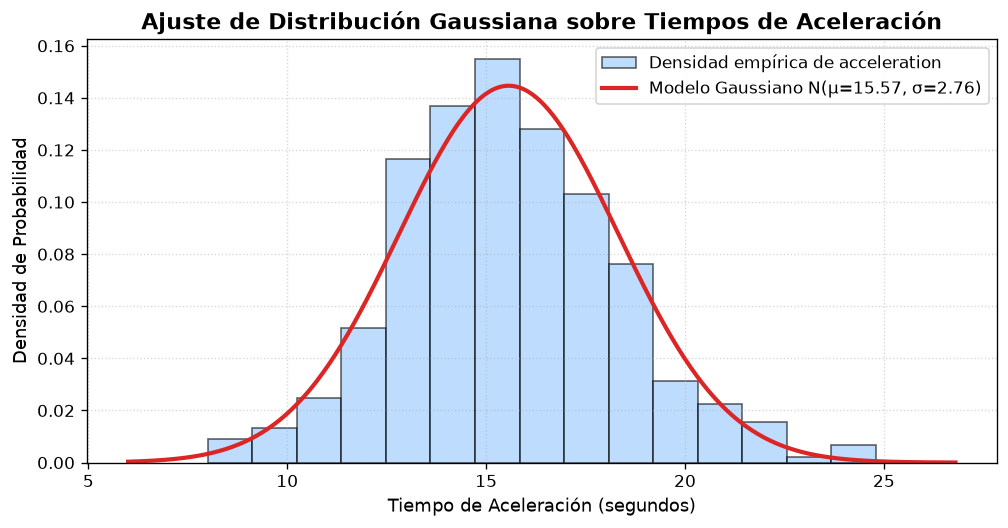

In [10]:
plt.figure(figsize=(8.5, 4.5))
plt.hist(df["acceleration"], bins=15, density=True, color="#93c5fd", edgecolor="black", alpha=0.6, label="Densidad empírica de acceleration")

x_range = np.linspace(df["acceleration"].min() - 2, df["acceleration"].max() + 2, 400)
pdf_curve = stats.norm.pdf(x_range, loc=mu_acc, scale=sigma_acc)
plt.plot(x_range, pdf_curve, color="#dc2626", linewidth=2.5, label=f"Modelo Gaussiano N(μ={mu_acc:.2f}, σ={sigma_acc:.2f})")

plt.title("Ajuste de Distribución Gaussiana sobre Tiempos de Aceleración", fontsize=13, fontweight="bold")
plt.xlabel("Tiempo de Aceleración (segundos)", fontsize=11)
plt.ylabel("Densidad de Probabilidad", fontsize=11)
plt.legend(frameon=True)
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()


**c) Crea un gráfico Q-Q (quantile-quantile plot) para evaluar qué tan bien se ajusta acceleration a una distribución normal. ¿Los datos siguen aproximadamente una distribución normal? Justifica.**


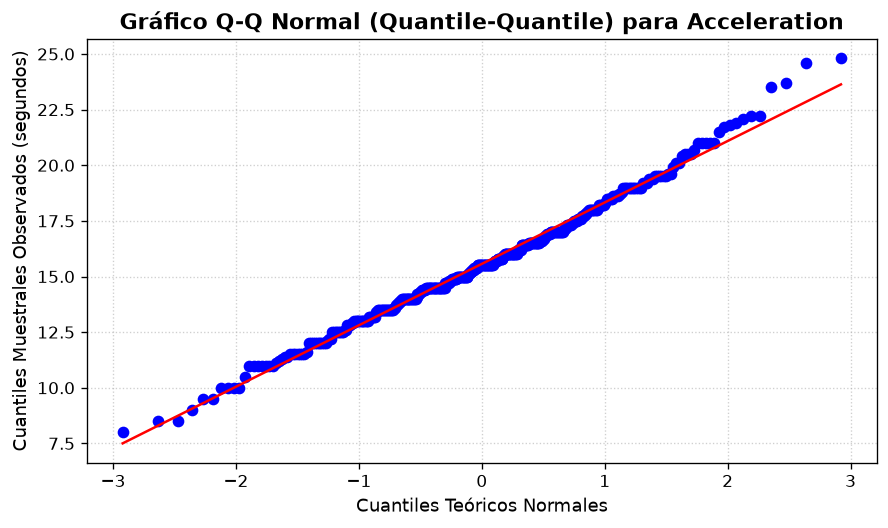

In [11]:
plt.figure(figsize=(7.5, 4.5))
stats.probplot(df["acceleration"], dist="norm", plot=plt)
plt.title("Gráfico Q-Q Normal (Quantile-Quantile) para Acceleration", fontsize=13, fontweight="bold")
plt.xlabel("Cuantiles Teóricos Normales", fontsize=11)
plt.ylabel("Cuantiles Muestrales Observados (segundos)", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()


*Respuesta:*

**sí, los datos siguen aproximadamente una distribución normal de manera muy satisfactoria**, notablemente mejor que variables con truncamiento o ceros.

en el gráfico q-q, la gran mayoría de las observaciones (entre los cuantiles teóricos -2.0 y +2.0) se alinean casi con exactitud sobre la recta teórica de 45°. las únicas divergencias menores ocurren en los extremos más alejados (cuantiles > 2.5), donde algunos vehículos lentos se dispersan ligeramente hacia arriba, pero el ajuste general es sólido y adecuado para modelado probabilístico.


### Cálculo de Probabilidades

Asumiendo que acceleration sigue una distribución normal con los parámetros estimados en el punto anterior, utiliza las funciones de apoyo `area_cdf`, `area_cdf_c` y `area_between`, según corresponda. Para los percentiles, utiliza la función `stats.norm.ppf` de scipy.

**a) ¿Cuál es la probabilidad de que un automóvil seleccionado al azar tarde menos de 13 segundos en acelerar de 0 a 60 mph?**


Z-score para acceleration = 13 s: -0.9312
Probabilidad P(acceleration < 13): 0.1759 (17.59%)


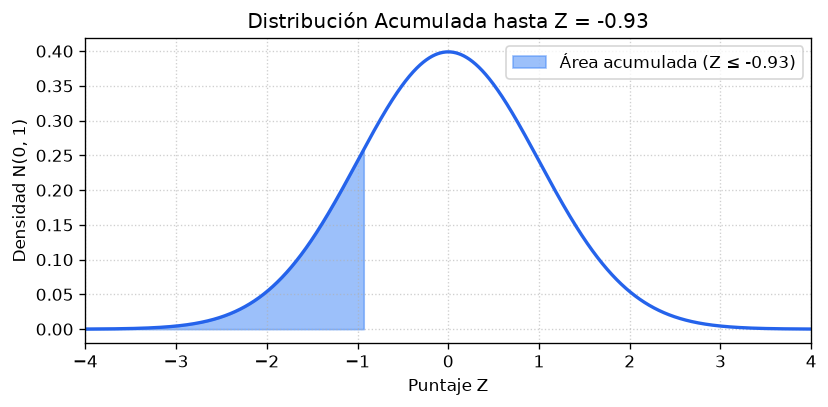

In [12]:
z_13 = (13 - mu_acc) / sigma_acc
prob_lt_13 = stats.norm.cdf(13, loc=mu_acc, scale=sigma_acc)

print(f"Z-score para acceleration = 13 s: {z_13:.4f}")
print(f"Probabilidad P(acceleration < 13): {prob_lt_13:.4f} ({prob_lt_13 * 100:.2f}%)")

area_cdf_impl(z_13)


**b) ¿Cuál es la probabilidad de que un automóvil seleccionado al azar tarde entre 15 y 19 segundos en acelerar de 0 a 60 mph?**


Z-score para acceleration = 15 s: -0.2060
Z-score para acceleration = 19 s: 1.2445
Probabilidad P(15 ≤ acceleration ≤ 19): 0.4749 (47.49%)


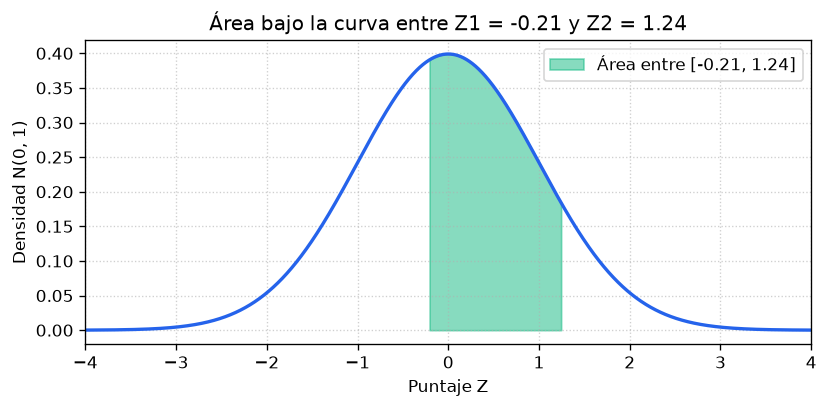

In [13]:
z_15 = (15 - mu_acc) / sigma_acc
z_19 = (19 - mu_acc) / sigma_acc
prob_15_19 = stats.norm.cdf(19, loc=mu_acc, scale=sigma_acc) - stats.norm.cdf(15, loc=mu_acc, scale=sigma_acc)

print(f"Z-score para acceleration = 15 s: {z_15:.4f}")
print(f"Z-score para acceleration = 19 s: {z_19:.4f}")
print(f"Probabilidad P(15 ≤ acceleration ≤ 19): {prob_15_19:.4f} ({prob_15_19 * 100:.2f}%)")

area_between_impl(z_15, z_19)


**c) Se clasificará como de "aceleración lenta" al 20% de los automóviles con los mayores tiempos de aceleración de 0 a 60 mph. ¿Cuál es el tiempo límite a partir del cual un automóvil pertenece a esta clasificación?**


In [14]:
tiempo_limite_lento = stats.norm.ppf(0.80, loc=mu_acc, scale=sigma_acc)
print(f"Percentil 80 (P80 - Corte 20% más lento): {tiempo_limite_lento:.4f} segundos (~{tiempo_limite_lento:.2f} s)")
print(f"Interpretación: Un automóvil pertenece a la clasificación de aceleración lenta si tarda {tiempo_limite_lento:.2f} segundos o más.")


Percentil 80 (P80 - Corte 20% más lento): 17.8890 segundos (~17.89 s)
Interpretación: Un automóvil pertenece a la clasificación de aceleración lenta si tarda 17.89 segundos o más.


**d) ¿Cuál es la probabilidad de que un automóvil seleccionado al azar tarde más de 17 segundos en acelerar de 0 a 60 mph?**


Z-score para acceleration = 17 s: 0.5192
Probabilidad P(acceleration > 17): 0.3018 (30.18%)


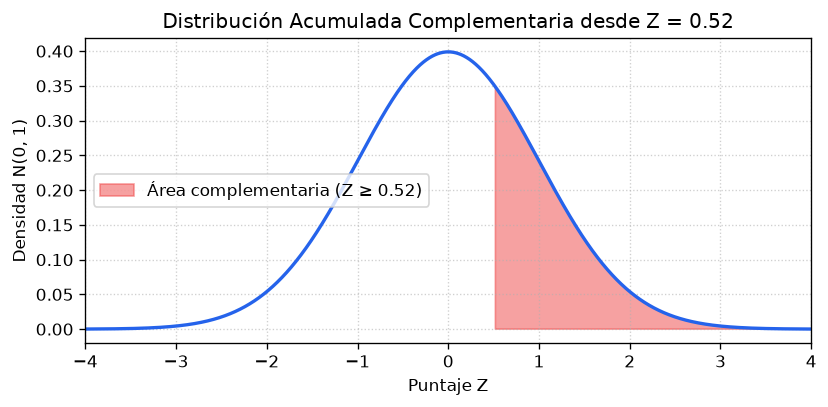

In [15]:
z_17 = (17 - mu_acc) / sigma_acc
prob_gt_17 = 1 - stats.norm.cdf(17, loc=mu_acc, scale=sigma_acc)

print(f"Z-score para acceleration = 17 s: {z_17:.4f}")
print(f"Probabilidad P(acceleration > 17): {prob_gt_17:.4f} ({prob_gt_17 * 100:.2f}%)")

area_cdf_c_impl(z_17)


### Interpretación y Aplicación

**a) Suponiendo que los tiempos de aceleración de 0 a 60 mph de un lote de 800 automóviles siguen el modelo gaussiano ajustado, ¿aproximadamente cuántos automóviles esperarías que tengan tiempos entre 13 y 16 segundos? Utiliza las funciones de apoyo y explica cómo conviertes la probabilidad en un número esperado de automóviles.**


Z-score para 13 s: -0.9312
Z-score para 16 s: 0.1566
Probabilidad P(13 ≤ acceleration ≤ 16): 0.3864 (38.64%)
Automóviles esperados en lote de 800: 309.09 (~309 automóviles)

Explicación: Por la linealidad de la esperanza matemática E[X] = N * P, se multiplica el tamaño del lote (800) por la probabilidad del intervalo (0.3864).


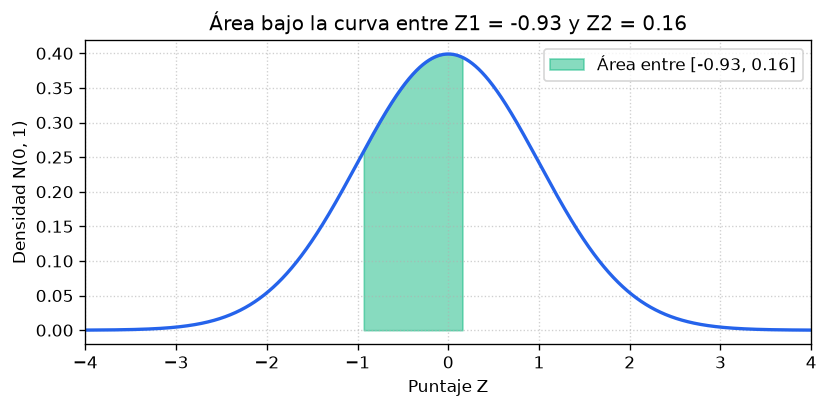

In [16]:
z_13_ap = (13 - mu_acc) / sigma_acc
z_16_ap = (16 - mu_acc) / sigma_acc
prob_13_16 = stats.norm.cdf(16, loc=mu_acc, scale=sigma_acc) - stats.norm.cdf(13, loc=mu_acc, scale=sigma_acc)
n_lote = 800
autos_esperados = n_lote * prob_13_16

print(f"Z-score para 13 s: {z_13_ap:.4f}")
print(f"Z-score para 16 s: {z_16_ap:.4f}")
print(f"Probabilidad P(13 ≤ acceleration ≤ 16): {prob_13_16:.4f} ({prob_13_16 * 100:.2f}%)")
print(f"Automóviles esperados en lote de {n_lote}: {autos_esperados:.2f} (~{round(autos_esperados)} automóviles)")
print(f"\nExplicación: Por la linealidad de la esperanza matemática E[X] = N * P, se multiplica el tamaño del lote (800) por la probabilidad del intervalo ({prob_13_16:.4f}).")

area_between_impl(z_13_ap, z_16_ap)


**b) Una revista de automóviles quiere seleccionar el 10% de autos con mejor aceleración (menor tiempo de 0 a 60 mph) para una categoría especial. Según el modelo gaussiano ajustado, ¿cuál debería ser el tiempo máximo para calificar? Utiliza `stats.norm.ppf` y expresa el resultado en segundos.**


In [17]:
tiempo_max_calificar = stats.norm.ppf(0.10, loc=mu_acc, scale=sigma_acc)
print(f"Percentil 10 (P10 - Tiempo Máximo Top 10% Rápido): {tiempo_max_calificar:.4f} segundos (~{tiempo_max_calificar:.2f} s)")
print(f"Para calificar a la categoría especial, un automóvil debe tardar como máximo {tiempo_max_calificar:.2f} segundos en acelerar de 0 a 60 mph.")


Percentil 10 (P10 - Tiempo Máximo Top 10% Rápido): 12.0340 segundos (~12.03 s)
Para calificar a la categoría especial, un automóvil debe tardar como máximo 12.03 segundos en acelerar de 0 a 60 mph.


**c) Reflexiona: ¿Consideras que el modelo de distribución normal es apropiado para modelar la aceleración de los automóviles? ¿Qué limitaciones podría tener este modelo?**

*Respuesta:*

el modelo de distribución normal es **muy apropiado como aproximación empírica univariada**, ya que los tiempos de aceleración se distribuyen de forma notablemente simétrica en torno a los 15.57 segundos y se ajustan con gran fidelidad a la recta en el gráfico q-q.

sin embargo, presenta **limitaciones físicas y operativas clave**:
1. **soporte infinito vs naturaleza estrictamente positiva ($t > 0$)**: la normal asigna probabilidad a valores negativos ($t < 0$), lo que es físicamente imposible. aunque para $\mu=15.57$ y $\sigma=2.76$ el valor 0 está a más de 5.6 desviaciones estándar ($P(X < 0) \approx 10^{-8}$), formalmente el soporte no está acotado.
2. **límites biomecánicos y de fricción**: ningún automóvil de combustión de la época podía acelerar en 0 o 1 segundo por límites de adherencia neumática y masa.
3. **reducción univariada**: la aceleración depende físicamente de una relación no lineal multivariada (potencia, torque, peso, aerodinámica y relación de transmisión). modelarla con una única gaussiana ignora estas interacciones físicas directas.


## Criterios de Evaluación

- **Justificación matemática y estadística**: 50%
- **Calidad del código y visualizaciones**: 25%
- **Interpretación y análisis crítico**: 25%

**Total: 100 puntos**
